In [17]:
import pandas as pd
df= pd.read_csv("D:\Mall_Customers.csv")
print(df.head)

<bound method NDFrame.head of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>


# MISSING VALUE ANALYSIS

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("🔍 COMPREHENSIVE MISSING VALUES ANALYSIS")
print("="*70)
print("\n📊 BASIC MISSING VALUES OVERVIEW:")
print("-" * 50)


missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
total_cells = df.shape[0] * df.shape[1]
total_missing = missing_count.sum()


missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_count,
    'Missing_Percentage': missing_percentage,
    'Data_Type': df.dtypes
}).sort_values('Missing_Count', ascending=False)

print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"Total cells: {total_cells:,}")
print(f"Total missing cells: {total_missing:,}")
print(f"Overall missing percentage: {(total_missing/total_cells)*100:.2f}%")

print("\n📋 DETAILED MISSING VALUES BY COLUMN:")
print("-" * 50)


columns_with_missing = missing_summary[missing_summary['Missing_Count'] > 0]

if not columns_with_missing.empty:
    print(columns_with_missing.to_string(index=False))
    
    print(f"\n📈 SUMMARY:")
    print(f"Columns with missing values: {len(columns_with_missing)}")
    print(f"Columns without missing values: {len(df.columns) - len(columns_with_missing)}")
    
else:
    print("✅ No missing values found in any column!")


if not columns_with_missing.empty:
    print("\n🏷️ MISSING VALUES CATEGORIZATION:")
    print("-" * 50)
    
   
    no_missing = missing_summary[missing_summary['Missing_Percentage'] == 0]
    low_missing = missing_summary[(missing_summary['Missing_Percentage'] > 0) & 
                                 (missing_summary['Missing_Percentage'] <= 5)]
    moderate_missing = missing_summary[(missing_summary['Missing_Percentage'] > 5) & 
                                      (missing_summary['Missing_Percentage'] <= 25)]
    high_missing = missing_summary[(missing_summary['Missing_Percentage'] > 25) & 
                                  (missing_summary['Missing_Percentage'] <= 50)]
    very_high_missing = missing_summary[missing_summary['Missing_Percentage'] > 50]
    
    print(f"✅ No missing (0%): {len(no_missing)} columns")
    if len(low_missing) > 0:
        print(f"🟢 Low missing (0-5%): {len(low_missing)} columns")
        print(f"   {list(low_missing['Column'])}")
    
    if len(moderate_missing) > 0:
        print(f"🟡 Moderate missing (5-25%): {len(moderate_missing)} columns")
        print(f"   {list(moderate_missing['Column'])}")
    
    if len(high_missing) > 0:
        print(f"🟠 High missing (25-50%): {len(high_missing)} columns")
        print(f"   {list(high_missing['Column'])}")
    
    if len(very_high_missing) > 0:
        print(f"🔴 Very high missing (>50%): {len(very_high_missing)} columns")
        print(f"   {list(very_high_missing['Column'])}")


if not columns_with_missing.empty:
    print("\n📊 GENERATING MISSING VALUES VISUALIZATIONS...")
    
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Missing Values Heatmap
    plt.subplot(2, 3, 1)
    # Only show columns with missing values for better visibility
    cols_to_show = columns_with_missing['Column'].tolist()
    if len(cols_to_show) > 20:  # Limit to 20 columns for readability
        cols_to_show = cols_to_show[:20]
    
    sns.heatmap(df[cols_to_show].isnull(), 
                cbar=True, 
                yticklabels=False, 
                cmap='viridis',
                cbar_kws={'label': 'Missing Values'})
    plt.title('Missing Values Heatmap\n(Yellow = Missing)', fontweight='bold')
    plt.xlabel('Columns')
    plt.subplot(2, 3, 2)
    top_missing = columns_with_missing.head(15)  # Top 15 columns with missing values
    bars = plt.bar(range(len(top_missing)), top_missing['Missing_Percentage'], 
                   color='coral', alpha=0.7)
    plt.title('Missing Values Percentage by Column', fontweight='bold')
    plt.xlabel('Columns')
    plt.ylabel('Missing Percentage (%)')
    plt.xticks(range(len(top_missing)), top_missing['Column'], rotation=45, ha='right')
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
    
    plt.subplot(2, 3, 3)
    bars = plt.bar(range(len(top_missing)), top_missing['Missing_Count'], 
                   color='lightblue', alpha=0.7)
    plt.title('Missing Values Count by Column', fontweight='bold')
    plt.xlabel('Columns')
    plt.ylabel('Missing Count')
    plt.xticks(range(len(top_missing)), top_missing['Column'], rotation=45, ha='right')
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + max(top_missing['Missing_Count'])*0.01,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
   
    plt.subplot(2, 3, 4)
    missing_matrix = df[cols_to_show].isnull().astype(int)
    plt.imshow(missing_matrix.T, cmap='RdYlBu', aspect='auto', interpolation='nearest')
    plt.title('Missing Values Matrix\n(Red = Missing)', fontweight='bold')
    plt.xlabel('Rows (Sample)')
    plt.ylabel('Columns')
    plt.yticks(range(len(cols_to_show)), cols_to_show)
    plt.subplot(2, 3, 5)
    missing_by_dtype = columns_with_missing.groupby('Data_Type')['Missing_Count'].sum().sort_values(ascending=False)
    colors = plt.cm.Set3(np.linspace(0, 1))

🔍 COMPREHENSIVE MISSING VALUES ANALYSIS

📊 BASIC MISSING VALUES OVERVIEW:
--------------------------------------------------
Total rows: 200
Total columns: 7
Total cells: 1,400
Total missing cells: 0
Overall missing percentage: 0.00%

📋 DETAILED MISSING VALUES BY COLUMN:
--------------------------------------------------
✅ No missing values found in any column!


Sample Customer Data Created:
   CustomerID  Age  Annual_Income  Spending_Score  Purchase_Frequency  \
0           1   56             84              61                  10   
1           2   69             86              48                  43   
2           3   46             41              19                  44   
3           4   32             23               4                  29   
4           5   60             76              35                  13   

   Average_Transaction  
0                  247  
1                  211  
2                  430  
3                  466  
4                  164  

Dataset shape: (200, 6)

Features selected for clustering: ['Annual_Income', 'Spending_Score', 'Purchase_Frequency', 'Average_Transaction']

Feature statistics:
       Annual_Income  Spending_Score  Purchase_Frequency  Average_Transaction
count     200.000000      200.000000          200.000000           200.000000
mean       76.180000       50.140000           25.660000       

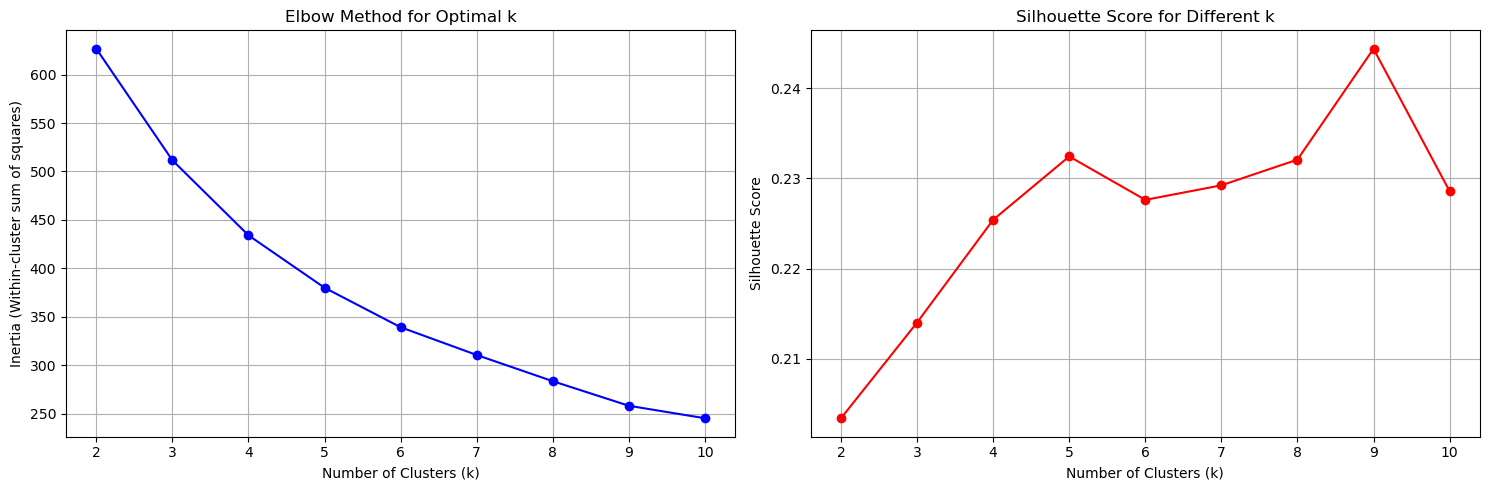


K-means clustering completed with k=4
Silhouette Score: 0.225

Cluster Analysis:
         Annual_Income  Spending_Score  Purchase_Frequency  \
Cluster                                                      
0            41.708333       37.770833           33.104167   
1            58.949153       78.966102           21.016949   
2            99.044444       30.355556            9.933333   
3           110.395833       45.625000           38.666667   

         Average_Transaction  
Cluster                       
0                 323.770833  
1                 176.186441  
2                 293.644444  
3                 303.437500  

Cluster sizes:
Cluster
0    48
1    59
2    45
3    48
Name: count, dtype: int64


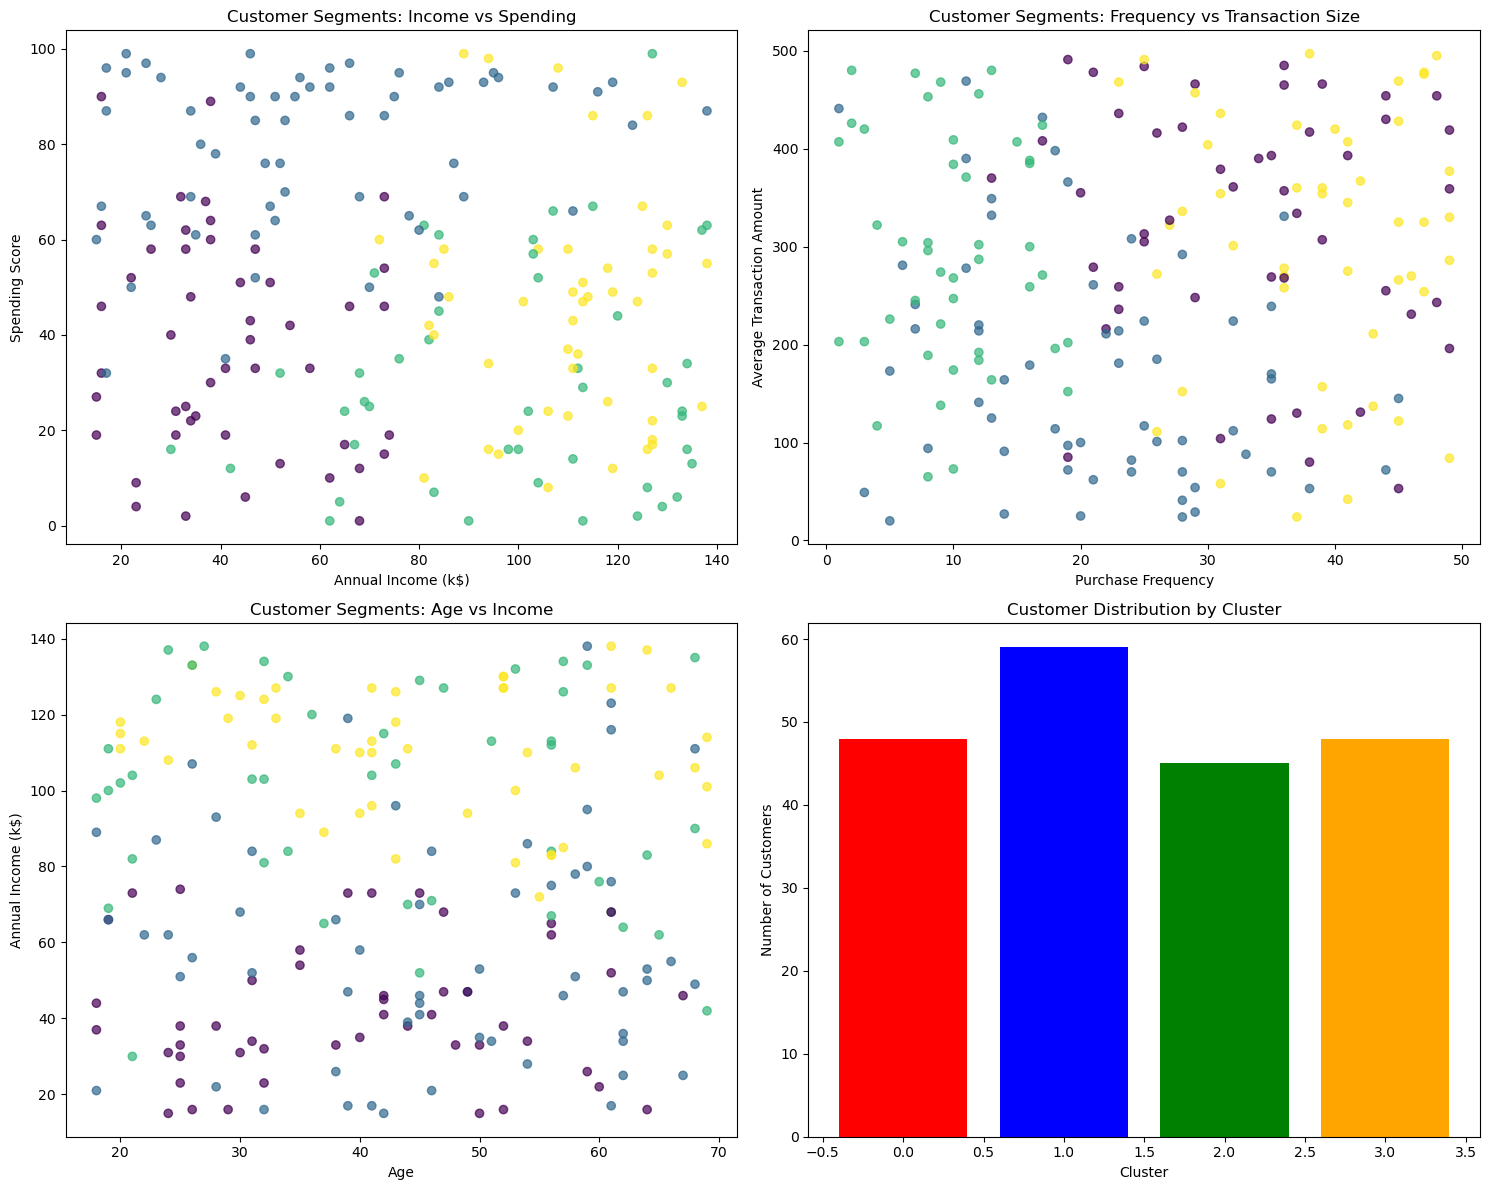


CUSTOMER SEGMENT INTERPRETATION

Cluster 0 - 'Budget Conscious':
  Size: 48 customers (24.0%)
  Avg Annual Income: $42k
  Avg Spending Score: 37.8/100
  Avg Purchase Frequency: 33.1 times/year
  Avg Transaction Amount: $324

Cluster 1 - 'High Value':
  Size: 59 customers (29.5%)
  Avg Annual Income: $59k
  Avg Spending Score: 79.0/100
  Avg Purchase Frequency: 21.0 times/year
  Avg Transaction Amount: $176

Cluster 2 - 'Frequent Shoppers':
  Size: 45 customers (22.5%)
  Avg Annual Income: $99k
  Avg Spending Score: 30.4/100
  Avg Purchase Frequency: 9.9 times/year
  Avg Transaction Amount: $294

Cluster 3 - 'Premium Customers':
  Size: 48 customers (24.0%)
  Avg Annual Income: $110k
  Avg Spending Score: 45.6/100
  Avg Purchase Frequency: 38.7 times/year
  Avg Transaction Amount: $303


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n_customers = 200

customer_data = {
    'CustomerID': range(1, n_customers + 1),
    'Age': np.random.randint(18, 70, n_customers),
    'Annual_Income': np.random.randint(15, 140, n_customers),  # in thousands
    'Spending_Score': np.random.randint(1, 100, n_customers),  # 1-100 scale
    'Purchase_Frequency': np.random.randint(1, 50, n_customers),  # purchases per year
    'Average_Transaction': np.random.randint(20, 500, n_customers)  # average purchase amount
}

df = pd.DataFrame(customer_data)
print("Sample Customer Data Created:")
print(df.head())
print(f"\nDataset shape: {df.shape}")

features = ['Annual_Income', 'Spending_Score', 'Purchase_Frequency', 'Average_Transaction']
X = df[features]

print(f"\nFeatures selected for clustering: {features}")
print("\nFeature statistics:")
print(X.describe())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeatures standardized successfully!")


inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster sum of squares)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)


ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Different k')
ax2.grid(True)

plt.tight_layout()
plt.show()


optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)


df['Cluster'] = cluster_labels

print(f"\nK-means clustering completed with k={optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.3f}")


print("\nCluster Analysis:")
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

print("\nCluster sizes:")
print(df['Cluster'].value_counts().sort_index())


fig, axes = plt.subplots(2, 2, figsize=(15, 12))


axes[0,0].scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'], cmap='viridis', alpha=0.7)
axes[0,0].set_xlabel('Annual Income (k$)')
axes[0,0].set_ylabel('Spending Score')
axes[0,0].set_title('Customer Segments: Income vs Spending')


axes[0,1].scatter(df['Purchase_Frequency'], df['Average_Transaction'], c=df['Cluster'], cmap='viridis', alpha=0.7)
axes[0,1].set_xlabel('Purchase Frequency')
axes[0,1].set_ylabel('Average Transaction Amount')
axes[0,1].set_title('Customer Segments: Frequency vs Transaction Size')


axes[1,0].scatter(df['Age'], df['Annual_Income'], c=df['Cluster'], cmap='viridis', alpha=0.7)
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Annual Income (k$)')
axes[1,0].set_title('Customer Segments: Age vs Income')


cluster_counts = df['Cluster'].value_counts().sort_index()
axes[1,1].bar(cluster_counts.index, cluster_counts.values, color=['red', 'blue', 'green', 'orange'])
axes[1,1].set_xlabel('Cluster')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].set_title('Customer Distribution by Cluster')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("CUSTOMER SEGMENT INTERPRETATION")
print("="*50)

for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    print(f"\nCluster {i} - '{['Budget Conscious', 'High Value', 'Frequent Shoppers', 'Premium Customers'][i]}':")
    print(f"  Size: {len(cluster_data)} customers ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"  Avg Annual Income: ${cluster_data['Annual_Income'].mean():.0f}k")
    print(f"  Avg Spending Score: {cluster_data['Spending_Score'].mean():.1f}/100")
    print(f"  Avg Purchase Frequency: {cluster_data['Purchase_Frequency'].mean():.1f} times/year")
    print(f"  Avg Transaction Amount: ${cluster_data['Average_Transaction'].mean():.0f}")